# **Personal Information**
### **Full name: Kleanthis Vasileiadis**  
### **sdi: 1115202200017**

# **All the necessery libraries used during this project**

In [1]:
#Library used for reading the data 
import pandas as pd
#Libraries used for working with arrays
import numpy as np
from scipy.sparse import vstack
#Libraries used for data visualization and plotting
pd.plotting.register_matplotlib_converters()
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from wordcloud import WordCloud
import nltk
from nltk.probability import FreqDist
#Libraries used for data preprocessing
import re
import emoji
import html
#Library used for vectorization
from sklearn.feature_extraction.text import TfidfVectorizer
#Library used for the machine learning model
from sklearn.linear_model import LogisticRegression
#Libraries used for evaluation
from sklearn.model_selection import learning_curve, PredefinedSplit
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, accuracy_score


# **Loading and reading the dataset**

In [2]:
#Reading the training data
train_data = pd.read_csv("/kaggle/input/ai-2-deep-learning-for-nlp-homework-1/train_dataset.csv")
X_train_data = train_data["Text"]
y_train_data = train_data["Label"]
print(f"Training data")
print(train_data.head(5))
print(f"\n")
#Reading the valuation data
val_data = pd.read_csv("/kaggle/input/ai-2-deep-learning-for-nlp-homework-1/val_dataset.csv")
X_val_data = val_data["Text"]
y_val_data = val_data["Label"]
print(f"Validation data")
print(val_data.head(5))
print(f"\n")
#Reading the testing data
test_data = pd.read_csv("/kaggle/input/ai-2-deep-learning-for-nlp-homework-1/test_dataset.csv")
X_test_data = test_data["Text"]
print(f"Testing data")
print(test_data.head(5))


Training data
       ID                                               Text  Label
0  189385      @whoisralphie dude  I'm so bummed ur leaving!      0
1   58036  oh my god, a severed foot was foun in a wheely...      0
2  190139  I end up &quot;dog dialing&quot; sumtimes. Wha...      1
3   99313                         @_rachelx meeeee toooooo!       0
4  157825  I was hoping I could stay home and work today,...      0


Validation data
       ID                                               Text  Label
0  187062  @NatexTheGreat heyheyhey maybe i will  get the...      0
1  168997  @molliesmummy Work? Work was crap. I missed yo...      0
2  194461  Want: Trip to Boston next month. Need: Addit'l...      1
3  165442                        first day starts tomorrow!       1
4   34853  @goodforyoursoul 8 course fish in Little Saigo...      1


Testing data
       ID                                               Text
0  102388  The books ARRIVED!!! Those who want a copy - w...
1  153802  @Spu

# **Initial analysis of the dataset with descriptive statistics and visualizations**

In [3]:
def stats_and_visuals(name, data):
    #General information
    print(f"\n{name} data info:")
    print(data.info())
    #Missing values
    print(f"\n{name} data missing values:")
    print(data.isnull().sum())
    if name != "Test":
        #Data frequency
        print(f"\n{name} data frequency:")
        print(data["Label"].value_counts())
        #Data frequency in percentage
        print(f"\n{name} data statistics:")
        print(data["Label"].value_counts(normalize=True))
        #Visuals
        #Plotting the distribution for the dataset
        ax = data.groupby("Label").count().plot(kind="bar", title="Distribution of data",legend=False)
        ax.set_xticklabels(["0","1"], rotation=0)
        text, sentiment = list(data["Text"]), list(data["Label"])

### Exploratory Data Analysis(EDA) for training data



Train data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148388 entries, 0 to 148387
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   ID      148388 non-null  int64 
 1   Text    148388 non-null  object
 2   Label   148388 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 3.4+ MB
None

Train data missing values:
ID       0
Text     0
Label    0
dtype: int64

Train data frequency:
Label
1    74196
0    74192
Name: count, dtype: int64

Train data statistics:
Label
1    0.500013
0    0.499987
Name: proportion, dtype: float64


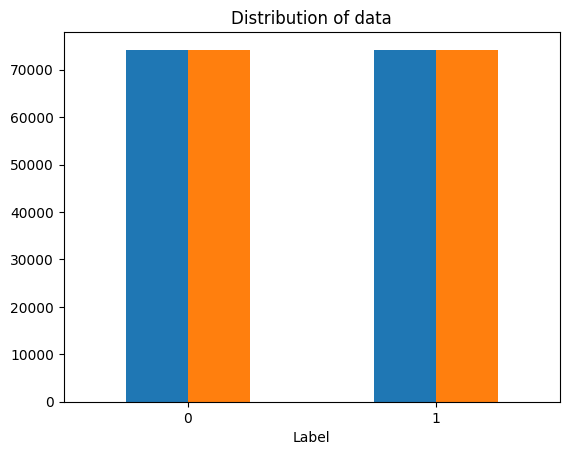

In [4]:
stats_and_visuals("Train",train_data)

### Exploratory Data Analysis(EDA) for validation data


Valuation data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42396 entries, 0 to 42395
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   ID      42396 non-null  int64 
 1   Text    42396 non-null  object
 2   Label   42396 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 993.8+ KB
None

Valuation data missing values:
ID       0
Text     0
Label    0
dtype: int64

Valuation data frequency:
Label
1    21199
0    21197
Name: count, dtype: int64

Valuation data statistics:
Label
1    0.500024
0    0.499976
Name: proportion, dtype: float64


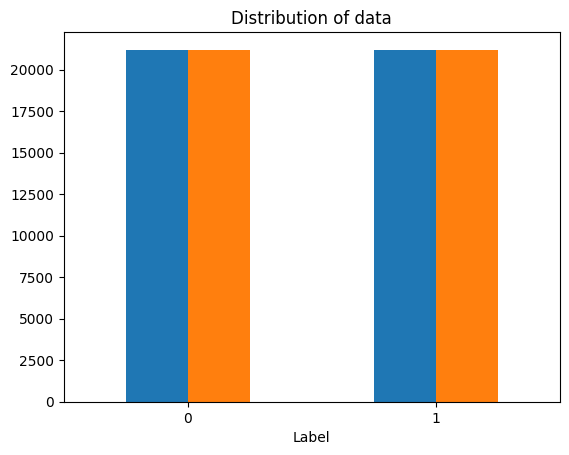

In [5]:
stats_and_visuals("Valuation",val_data)

### Exploratory Data Analysis(EDA) for Testing data

In [6]:
stats_and_visuals("Test",test_data)


Test data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21199 entries, 0 to 21198
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   ID      21199 non-null  int64 
 1   Text    21199 non-null  object
dtypes: int64(1), object(1)
memory usage: 331.4+ KB
None

Test data missing values:
ID      0
Text    0
dtype: int64


### **Lists and dictionaries of tokens to be replaced**

In [7]:
negation_words = {
            "not", "no", "never", "cannot", "won't", "don't", "doesn't", "isn't",
            "wasn't", "shouldn't", "couldn't", "wouldn't", "ain't", "didn't",
            "can't", "haven't", "hasn't", "nt", "wont", "dont", "doesnt", "isnt",
            "wasnt", "shouldnt", "couldnt", "wouldnt", "aint", "didnt"}

html_entities = {
            "&quot;": '"',         
            "&amp;": "and",         
            "&lt;": "less than",    
            "&gt;": "greater than"}

emoticons = {
        "<3": "love", 
        ":)": "happy", 
        ":-)": "happy", 
        ";)": "wink", 
        ":D": "laugh",
        ":(": "sad",
        ":o": "surprised",
        "XD": "laughing",
        "xD": "laughing",
        ":|": "neutral"}

names = [
    "john", "mary", "michael", "sarah", "james", "jennifer", "david", "robert", 
    "elizabeth", "william", "barbara", "richard", "susan", "joseph", "thomas", 
    "nancy", "charles", "karen", "betty", "matthew", "sandra", "anthony", "ashley", 
    "mark", "kimberly", "donald", "emily", "steven", "brian", "george", "edward", 
    "kevin", "ronald", "timothy", "becky", "farrah", "lisa", "alex", "kevin", "jenna", 
    "natalie", "matt", "bryan", "paul", "susan", "nikki", "carlos", "ben", "greta",
    "phil", "mia"]

places = [
    "nyc", "los angeles", "chicago", "houston","philadelphia","san antonio", "san diego",
    "dallas", "san jose", "austin", "jacksonville", "fort worth", "columbus", "san francisco",
    "charlotte", "seattle", "denver", "washington", "boston", "el paso", "nashville", "detroit", 
    "memphis", "portland", "las vegas", "louisville", "china", "asia", "america", "glasgow", 
    "melbourne", "dublin", "sydney", "california", "la", "tennesse", "dc", "texas", "portland", 
    "barcelona", "mexico", "australia", "europe", "germany", "spain", "alaska", "vancouver", 
    "munich", "greece", "japan", "mississippi", "peru", "bristol", "argentina", "denmark"]

terrains = [
        "island", "city", "town", "village", "country", "continent", "desert", "ocean", "river", 
        "mountain", "valley", "forest", "jungle", "beach", "canal", "county"]

# **All the text preprocessing done to the dataset**

In [8]:
#Replacing terrains
def replace_terrains(text):
    for terrain in terrains:
        text = re.sub(rf"\b{terrain}\b", "terrain", text, flags=re.IGNORECASE)
    return text
    
#Replacing emoticons
def replace_emoticons(text):
    for emoticon, replacement in emoticons.items():
        text = text.replace(emoticon, replacement)
    return text
    
#Replacing places
def replace_places(text):
    for place in places:
        text = re.sub(rf"\b{place}\b", "place", text, flags=re.IGNORECASE)
    return text

#Replacing names
def replace_names(text):
    for name in names:
        text = re.sub(rf"\b{name}\b", "name", text, flags=re.IGNORECASE)
    return text

#Replacing html_entities
def replace_html_entities(text):
    for entity, char in html_entities.items():
        text = text.replace(entity, char)
    return text

#Handling negation
def handle_negation(text):
    words = nltk.word_tokenize(text)
    negation = False
    new_words = []
    #For every word in the dataset
    for word in words:
        #If the word is in the negation list
        if word in negation_words:
            negation = True
            new_words.append(word)
        #"not_" is added to the next word
        elif negation:
            new_words.append("not_" + word)
            negation = False
        else:
            new_words.append(word)
    
    return " ".join(new_words)

def custom_preprocessor(text):
    #Replacing emojis
    text = emoji.replace_emoji(text, replace="emoji")
    #Replacing emoticons
    text = replace_emoticons(text)
    #Replacing HTML entities
    text = replace_html_entities(text) 
    #Replacing mentions
    text = re.sub(r"@\w+", "mention", text)
    #Replacing links
    text = re.sub(r"http[s]?://\S+|www\.\S+","link",text)
    #Replacing money
    text = re.sub(r"\$\d+(?:\.\d+)?|\€\d+(?:\.\d+)?", "money", text)
    #Replacing dates
    text = re.sub(r"\b\d{1,2}[-/]\d{1,2}[-/]\d{2,4}\b", "date", text)
    #Replacing months
    text = re.sub(r"\b(?:Jan|January|Feb|February|Mar|March|Apr|April|May|Jun|June|Jul|July|Aug|August|Sep|September|Oct|October|Nov|November|Dec|December)\b", "month", text)
    #Replacing emails
    text = re.sub(r"[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}", "email", text)
    #Replacing phones
    text = re.sub(r"\+?\d{1,3}[-.\s]?\(?\d{1,4}\)?[-.\s]?\d{3,4}[-.\s]?\d{3,4}", "phone", text)
    #Replacing credit cards
    text = re.sub(r"\b(?:\d[ -]*?){13,16}\b", "creditcard", text)
    #Replacing ip adresses
    text = re.sub(r"\b\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}\b", "ip", text)
    #Replacing time
    text = re.sub(r"\b(?:[01]?[0-9]|2[0-3]):[0-5][0-9]\b|\b(?:[0-9]{1,2}):[0-5][0-9]\s?(?:AM|PM)?\b", "time", text)
    #Replacing numbers
    text = re.sub(r"\b\d+\b", "number", text)
    #Replacing names
    text = replace_names(text)
    #Replacing places
    text = replace_places(text)
    #Replacing terrains
    text = replace_terrains(text)
    #Removing special characters i.e. keeping only letters
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    #Restricting repeated consecutive characters to a maximum of two
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)
    #Normalizing words to lowercase
    text = text.lower()
    #Handling negation
    text = handle_negation(text)

    return text
    
def custom_tokenizer(text):
    #Tokenizing the cleaned text
    words = text.split() 
    
    return words

### **Applying text preprocessing to all datasets and printing the cleaned text**

In [9]:
train_data["Text"] = train_data["Text"].apply(lambda x: custom_preprocessor(x))
X_train_data = train_data["Text"]
y_train_data = train_data["Label"]
print(f"\nCleaned training data")
print(train_data["Text"].head(10))

val_data["Text"] = val_data["Text"].apply(lambda x: custom_preprocessor(x))
X_val_data = val_data["Text"]
y_val_data = val_data["Label"]
print(f"\nCleaned validation data")
print(val_data["Text"].head(10))

test_data["Text"] = test_data["Text"].apply(lambda x: custom_preprocessor(x))
X_test_data = test_data["Text"]
print(f"\nCleaned test data")
print(test_data["Text"].head(10))


Cleaned training data
0                 mention dude im so bummed ur leaving
1    oh my god a severed foot was foun in a wheely ...
2    i end up dog dialing sumtimes whats dog dialin...
3                                      mention mee too
4    i was hoping i could stay home and work today ...
5    says plurk karma finally reached the s still n...
6    good to hear it mention this is a bit more but...
7    mention in that case im gon na start tweeting ...
8                 mention its alright love how are you
9    mention haha that has to be the best analogy e...
Name: Text, dtype: object

Cleaned validation data
0    mention heyheyhey maybe i will get them if i c...
1    mention work work was crap i missed your conde...
2    want trip to place next month need additl moti...
3                            first day starts tomorrow
4    mention number course fish in little saigon an...
5    no not_milk for breakfast grr but looks like a...
6    mention im signed up to get news updates 

# Word clouds and tokens frequency for all datasets


### **Positive words on training dataset**

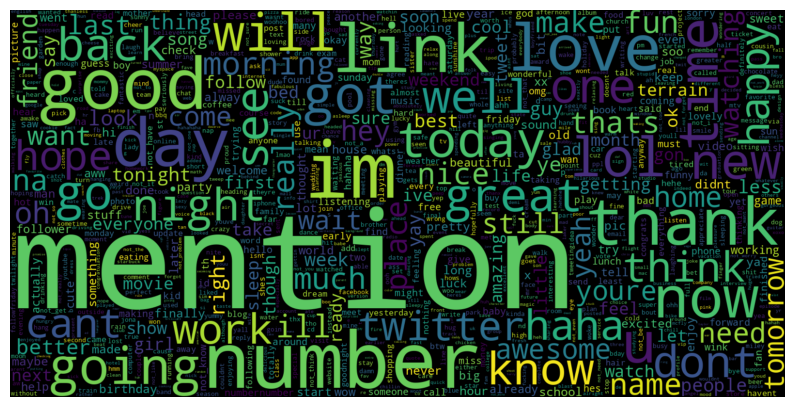

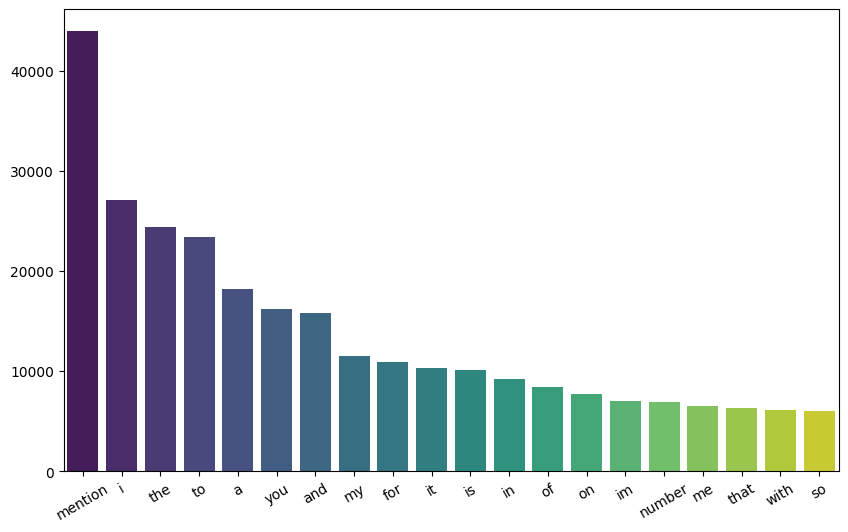

In [10]:
#Word cloud on training dataset
train = " ".join(train_data.query("Label==1")["Text"])
plt.figure(figsize=(10,10))
wc = WordCloud(max_words=1000,width=1600,height=800,collocations=False).generate(train)
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()

#Splitting the positive data
pos_tokens = train.split()
#Computing the frequency of each word
freq_dist = FreqDist(pos_tokens)
most_common_words = freq_dist.most_common(20)
#Converting to panda series
df_freq_dist = pd.Series(dict(most_common_words))
#Making the final plot
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=df_freq_dist.index, y=df_freq_dist.values, ax=ax, palette="viridis")
plt.xticks(rotation=30)
plt.show()

### **Negative words on training dataset**

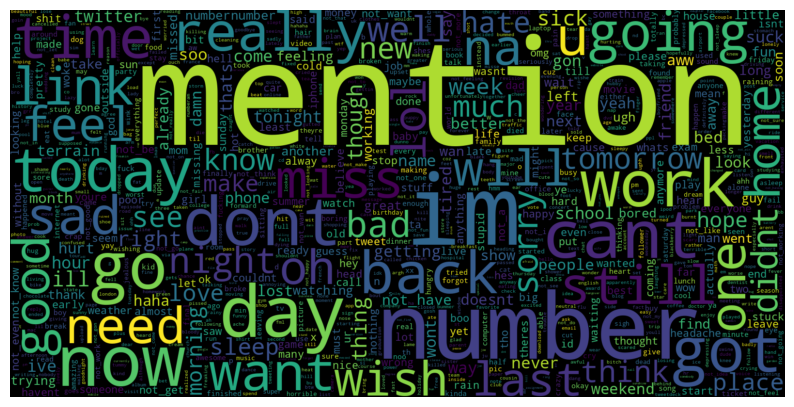

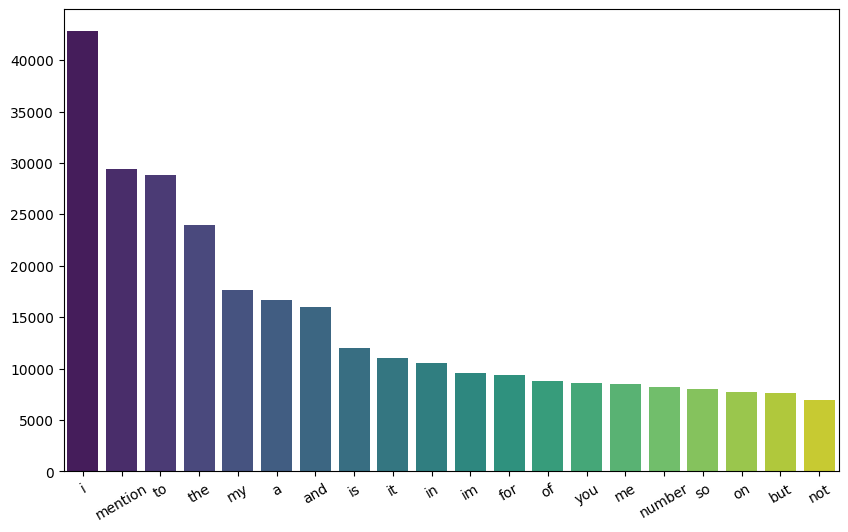

In [11]:
#Word cloud on training dataset
train = " ".join(train_data.query("Label==0")["Text"])
plt.figure(figsize=(10,10))
wc = WordCloud(max_words=1000,width=1600,height=800,collocations=False).generate(train)
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()

#Splitting the negative data
neg_tokens = train.split()
#Computing the frequency of each word
freq_dist = FreqDist(neg_tokens)
most_common_words = freq_dist.most_common(20)
#Converting to panda series
df_freq_dist = pd.Series(dict(most_common_words))
#Making the final plot
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=df_freq_dist.index, y=df_freq_dist.values, ax=ax, palette="viridis")
plt.xticks(rotation=30)
plt.show()

### **Positive words on validation dataset**

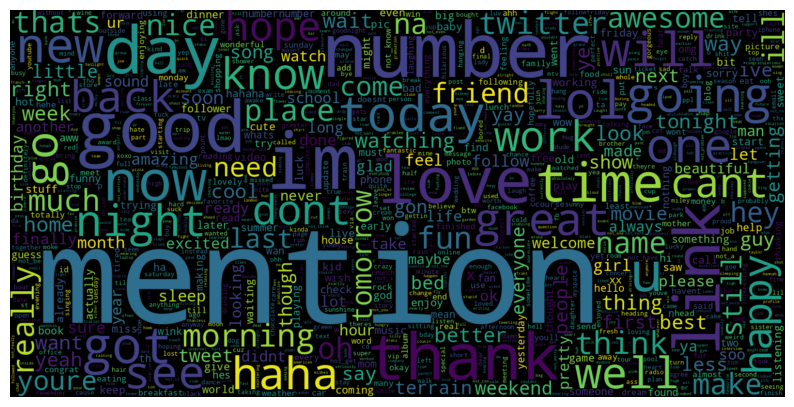

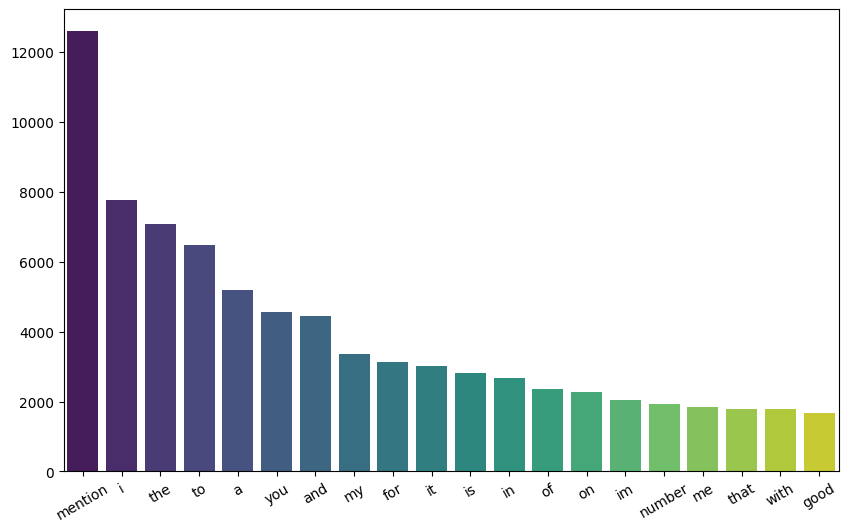

In [12]:
#Word cloud on validation dataset
val = " ".join(val_data.query("Label==1")["Text"])
plt.figure(figsize = (10,10))
wc = WordCloud(max_words=1000,width=1600,height=800,collocations=False).generate(val)
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()

#Splitting the positive data
pos_tokens = val.split()
#Computing the frequency of each word
freq_dist = FreqDist(pos_tokens)
most_common_words = freq_dist.most_common(20)
#Converting to panda series
df_freq_dist = pd.Series(dict(most_common_words))
#Making the final plot
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=df_freq_dist.index, y=df_freq_dist.values, ax=ax, palette="viridis")
plt.xticks(rotation=30)
plt.show()

### **Negative words on validation dataset**

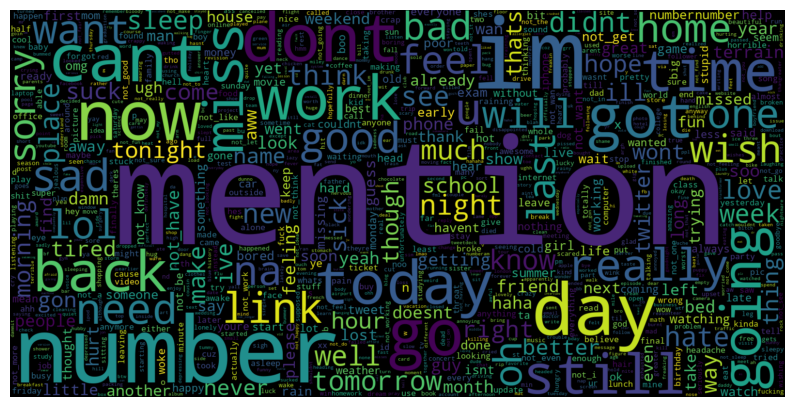

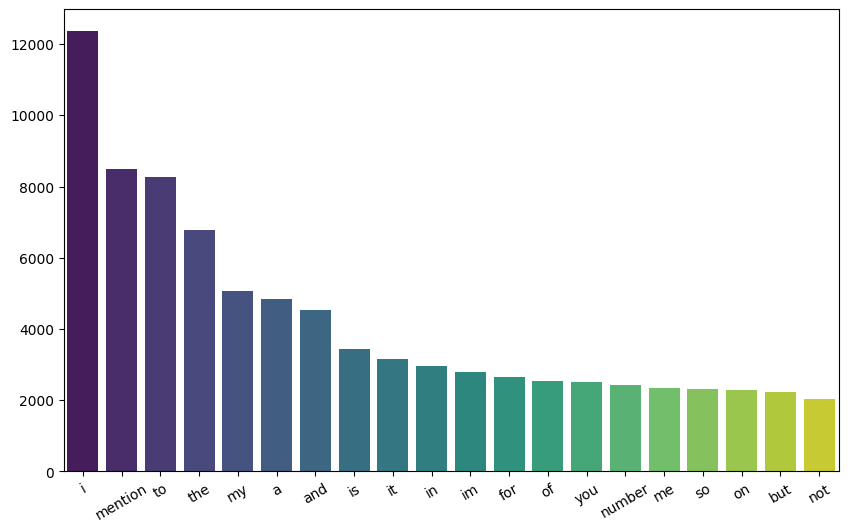

In [13]:
#Word cloud on validation dataset
val = " ".join(val_data.query("Label==0")["Text"])
plt.figure(figsize = (10,10))
wc = WordCloud(max_words=1000,width=1600,height=800,collocations=False).generate(val)
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()

#Splitting the negative data
neg_tokens = val.split()
#Computing the frequency of each word
freq_dist = FreqDist(neg_tokens)
most_common_words = freq_dist.most_common(20)
#Converting to panda series
df_freq_dist = pd.Series(dict(most_common_words))
#Making the final plot
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=df_freq_dist.index, y=df_freq_dist.values, ax=ax, palette="viridis")
plt.xticks(rotation=30)
plt.show()

### **Testing dataset**

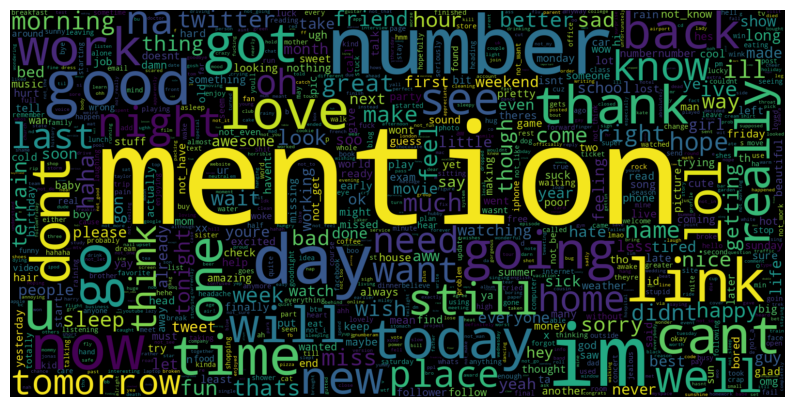

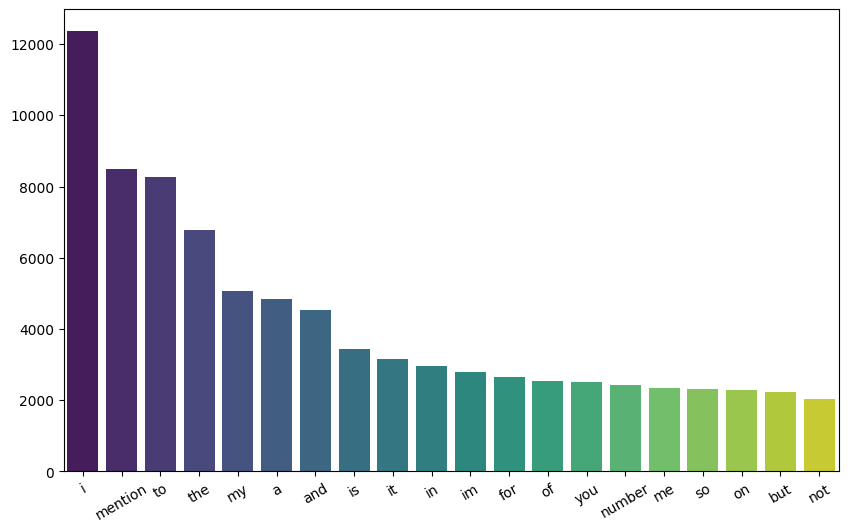

In [14]:
#Word cloud on testing dataset
test = " ".join(test_data["Text"])
plt.figure(figsize=(10,10))
wc = WordCloud(max_words=1000,width=1600,height=800,collocations=False).generate(test)
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()

#Splitting the data
tokens = test.split()
#Computing the frequency of each word
freq_dist = FreqDist(neg_tokens)
most_common_words = freq_dist.most_common(20)
#Converting to panda series
df_freq_dist = pd.Series(dict(most_common_words))
#Making the final plot
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=df_freq_dist.index, y=df_freq_dist.values, ax=ax, palette="viridis")
plt.xticks(rotation=30)
plt.show()

# Transforming the Dataset Using TF-IDF Vectorizer

In [15]:
vectorizer = TfidfVectorizer(tokenizer=custom_tokenizer,token_pattern=None,ngram_range=(1,3),max_df=0.95,min_df=2,max_features=15000,sublinear_tf=True)
#Fitting the tfidfVectorizer and printing its featured words
X_train_tfidf = vectorizer.fit_transform(X_train_data)
X_val_tfidf = vectorizer.transform(X_val_data)
X_test_tfidf = vectorizer.transform(X_test_data)
print("Number of feature words in training set: ", len(vectorizer.get_feature_names_out()))

Number of feature words in training set:  15000


# Building the model using Logistic Regression

In [16]:
model = LogisticRegression(C=0.3,solver="saga",random_state=42,max_iter=500)
#Training the model on the training dataset
model.fit(X_train_tfidf,y_train_data)
#Predictions on the training dataset
y_train_pred = model.predict(X_train_tfidf)
#Predictions on the valuation dataset
y_val_pred = model.predict(X_val_tfidf)
#Predictions on the testing dataset
y_test_pred = model.predict(X_test_tfidf)

#Creating the submission csv file
submission_data = {
    "ID": test_data["ID"],
    "Label": y_test_pred,
}
submission = pd.DataFrame(submission_data)
submission.to_csv("submission.csv", index=False)

# Model valuation

### ROC Curve

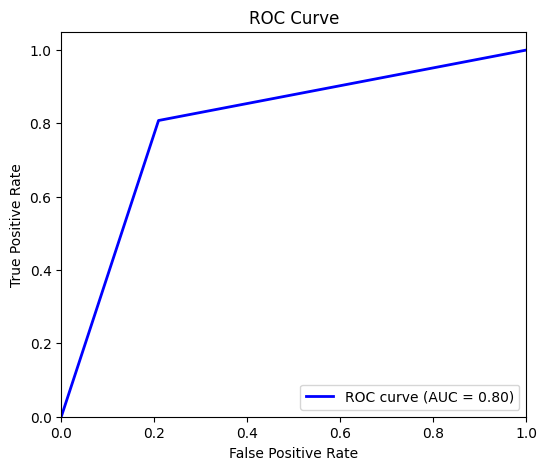

In [17]:
def ROC_curve(y_val_data,y_val_pred):
    #Computing the ROC curve
    fpr, tpr, thresholds = roc_curve(y_val_data, y_val_pred)
    roc_auc = auc(fpr, tpr)
    
    #Plotting the ROC curve
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc="lower right")
    plt.show()

ROC_curve(y_val_data,y_val_pred)

#### Learning curve

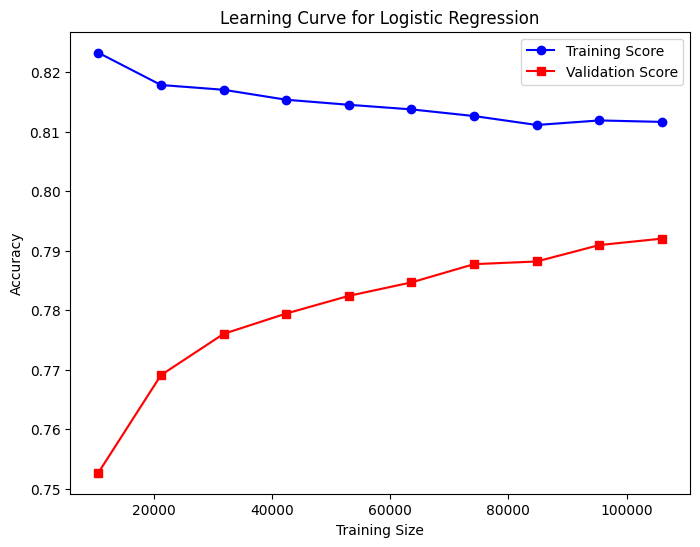

In [18]:
# Initialize test_fold with -1, meaning all data points are for training
test_fold = np.full(y_train_data.shape, -1)  
# Set the first N samples (equal to the validation set size) as validation (marked with 0)
test_fold[:len(y_val_data)] = 0  
# Create a PredefinedSplit using the specified train/validation split
ps = PredefinedSplit(test_fold)

#Creating the learning curve
train_sizes, train_scores, test_scores = learning_curve(
    LogisticRegression(C=0.3,solver="saga",random_state=42,max_iter=500), X_train_tfidf, y_train_data, cv=ps, 
    scoring="accuracy", train_sizes=np.linspace(0.1, 1.0, 10)
)

#Computing mean and std of accuracy
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

#Plottting the learning curve
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, label="Training Score", color="blue", marker="o")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="blue")

plt.plot(train_sizes, test_mean, label="Validation Score", color="red", marker="s")
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="red")

plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve for Logistic Regression")
plt.legend()
plt.show()

### Classification Report and Confusion Matrix


              precision    recall  f1-score   support

           0       0.80      0.79      0.80     21197
           1       0.79      0.81      0.80     21199

    accuracy                           0.80     42396
   macro avg       0.80      0.80      0.80     42396
weighted avg       0.80      0.80      0.80     42396



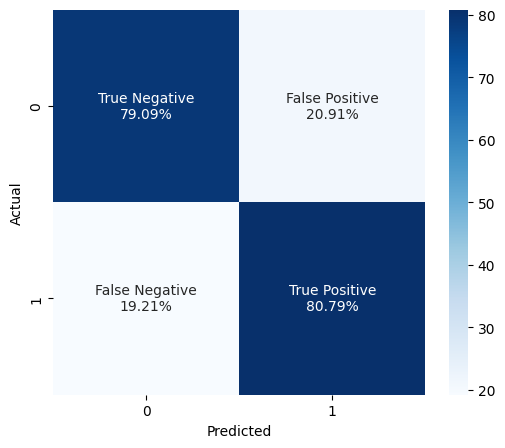

In [19]:
def cr_and_cm(y_val_data,y_val_pred):
    
    print(classification_report(y_val_data, y_val_pred))
    
    #Creating the confusion matrix
    cm = confusion_matrix(y_val_data, y_val_pred)
    #Converting the values to percentages
    cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100  
    #Creating the lists
    labels = np.array([["True Negative", "False Positive"], ["False Negative", "True Positive"]])
    cm_labels = np.array([[f"{labels[i, j]}\n{cm_percentage[i, j]:.2f}%" for j in range(2)] for i in range(2)])
    
    #Plotting the confusion matrix
    plt.figure(figsize=(6,5))
    sns.heatmap(cm_percentage, annot=cm_labels, fmt="", cmap="Blues", xticklabels=['0', '1'], yticklabels=['0', '1'])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

cr_and_cm(y_val_data,y_val_pred)

# Appendices

### In the following part im going to display some approaches that werent optimal
### 1) Basic model without any hyperparameters and text preprocessing
### Not optimal performance - Overfit present
### Accuracy on testing dataset: 0.78937

              precision    recall  f1-score   support

           0       0.79      0.79      0.79     21197
           1       0.79      0.80      0.79     21199

    accuracy                           0.79     42396
   macro avg       0.79      0.79      0.79     42396
weighted avg       0.79      0.79      0.79     42396



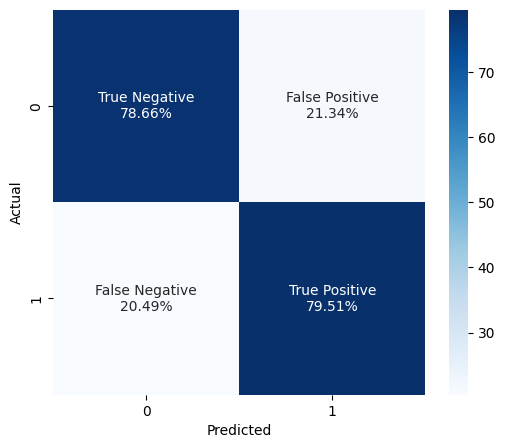

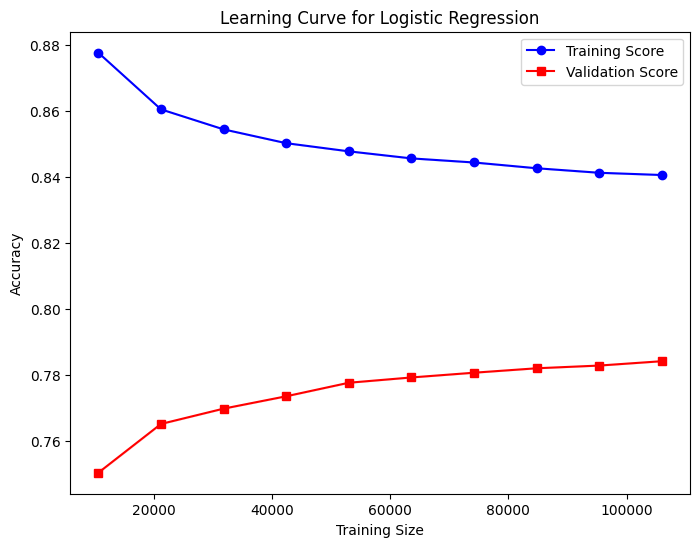

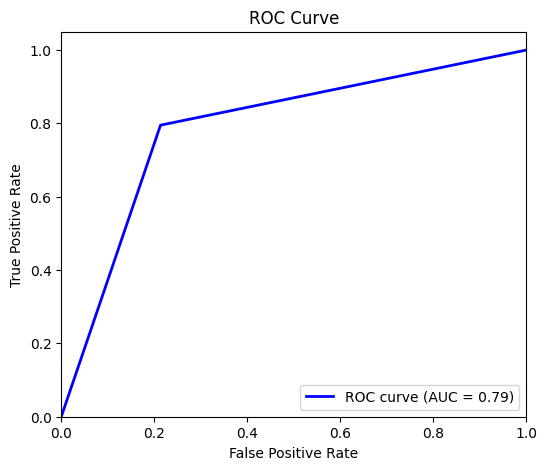

In [20]:
#Reading the training data
train_data = pd.read_csv("/kaggle/input/ai-2-deep-learning-for-nlp-homework-1/train_dataset.csv")
X_train_data = train_data["Text"]
y_train_data = train_data["Label"]
#Reading the valuation data
val_data = pd.read_csv("/kaggle/input/ai-2-deep-learning-for-nlp-homework-1/val_dataset.csv")
X_val_data = val_data["Text"]
y_val_data = val_data["Label"]

vectorizer = TfidfVectorizer()
#Fitting the tfidfVectorizer and transforming the data
X_train_tfidf = vectorizer.fit_transform(X_train_data)
X_val_tfidf = vectorizer.transform(X_val_data)

model = LogisticRegression(random_state=42,max_iter=500)
#Training the model on the training dataset
model.fit(X_train_tfidf,y_train_data)
#Predictions on the training dataset
y_train_pred = model.predict(X_train_tfidf)
#Predictions on the valuation dataset
y_val_pred = model.predict(X_val_tfidf)

#Classification report and confusion matrix
cr_and_cm(y_val_data,y_val_pred)

#Initializing test_fold with -1, meaning all data points are for training
test_fold = np.full(y_train_data.shape, -1)  
#Setting the validation dataset
test_fold[:len(y_val_data)] = 0  
#Creating the PredefinedSplit
ps = PredefinedSplit(test_fold)

#Creating the learning curve
train_sizes, train_scores, test_scores = learning_curve(
    LogisticRegression(random_state=42,max_iter=500), X_train_tfidf, y_train_data, cv=ps, scoring="accuracy", train_sizes=np.linspace(0.1, 1.0, 10)
)
#Computing mean and std of accuracy
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)
#Plotting the learning curve
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, label="Training Score", color="blue", marker="o")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="blue")
plt.plot(train_sizes, test_mean, label="Validation Score", color="red", marker="s")
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="red")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve for Logistic Regression")
plt.legend()
plt.show()

#ROC curve
ROC_curve(y_val_data,y_val_pred)

### 2) Basic model without any hyperparameters and with text preprocessing
### Still not optimal performance - Overfit present
### Accuracy on testing dataset: 0,78947

              precision    recall  f1-score   support

           0       0.80      0.79      0.80     21197
           1       0.79      0.80      0.80     21199

    accuracy                           0.80     42396
   macro avg       0.80      0.80      0.80     42396
weighted avg       0.80      0.80      0.80     42396



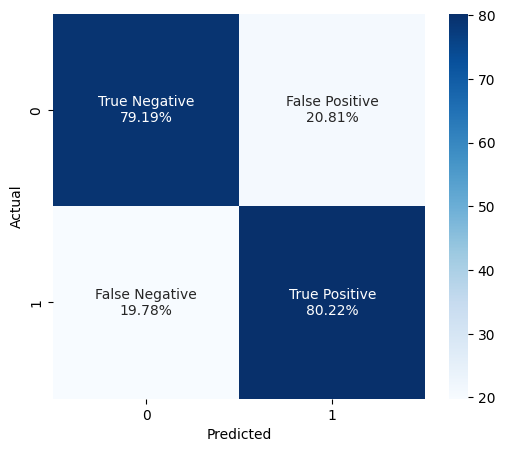

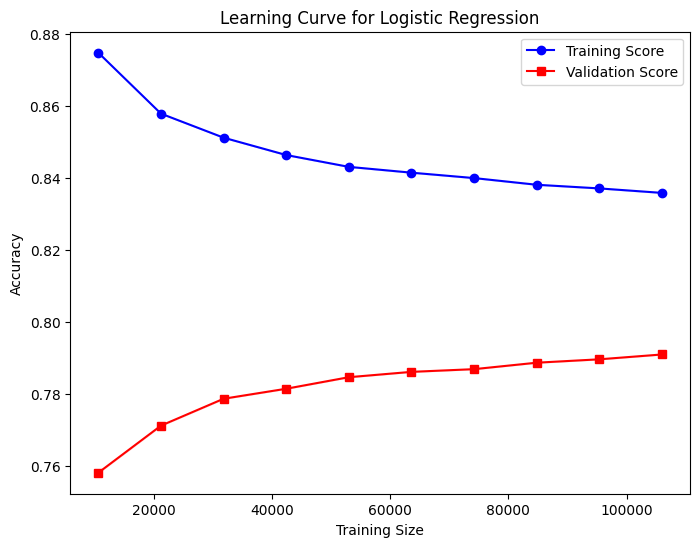

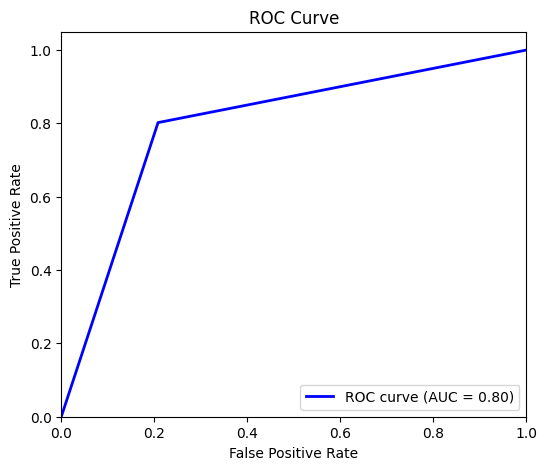

In [21]:
#Reading the training data
train_data["Text"] = train_data["Text"].apply(lambda x: custom_preprocessor(x))
X_train_data = train_data["Text"]
y_train_data = train_data["Label"]
#Reading the validation data
val_data["Text"] = val_data["Text"].apply(lambda x: custom_preprocessor(x))
X_val_data = val_data["Text"]
y_val_data = val_data["Label"]

vectorizer = TfidfVectorizer()
#Fitting the tfidfVectorizer and transforming the data
X_train_tfidf = vectorizer.fit_transform(X_train_data)
X_val_tfidf = vectorizer.transform(X_val_data)

model = LogisticRegression(random_state=42,max_iter=500)
#Training the model on the training dataset
model.fit(X_train_tfidf,y_train_data)
#Predictions on the training dataset
y_train_pred = model.predict(X_train_tfidf)
#Predictions on the valuation dataset
y_val_pred = model.predict(X_val_tfidf)

#Classification report and confusion matrix
cr_and_cm(y_val_data,y_val_pred)

#Initializing test_fold with -1, meaning all data points are for training
test_fold = np.full(y_train_data.shape, -1)  
#Setting the validation dataset
test_fold[:len(y_val_data)] = 0  
#Creating the PredefinedSplit
ps = PredefinedSplit(test_fold)

#Creating the learning curve
train_sizes, train_scores, test_scores = learning_curve(
    LogisticRegression(random_state=42,max_iter=500), X_train_tfidf, y_train_data, cv=ps, scoring="accuracy", train_sizes=np.linspace(0.1, 1.0, 10)
)
#Computing mean and std of accuracy
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

#Plotting the learning curve
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, label="Training Score", color="blue", marker="o")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="blue")
plt.plot(train_sizes, test_mean, label="Validation Score", color="red", marker="s")
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="red")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve for Logistic Regression")
plt.legend()
plt.show()

#ROC curve
ROC_curve(y_val_data,y_val_pred)

### 3)Model without any hyperparameters and with stemming and removal of stop words added to the preprocessing
### Worse performance - Overfit present
### Accuracy on testing dataset: 0.73022

              precision    recall  f1-score   support

           0       0.78      0.76      0.77     21197
           1       0.77      0.79      0.78     21199

    accuracy                           0.78     42396
   macro avg       0.78      0.78      0.78     42396
weighted avg       0.78      0.78      0.78     42396



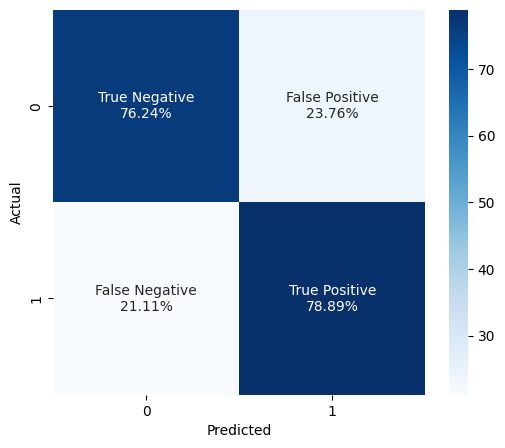

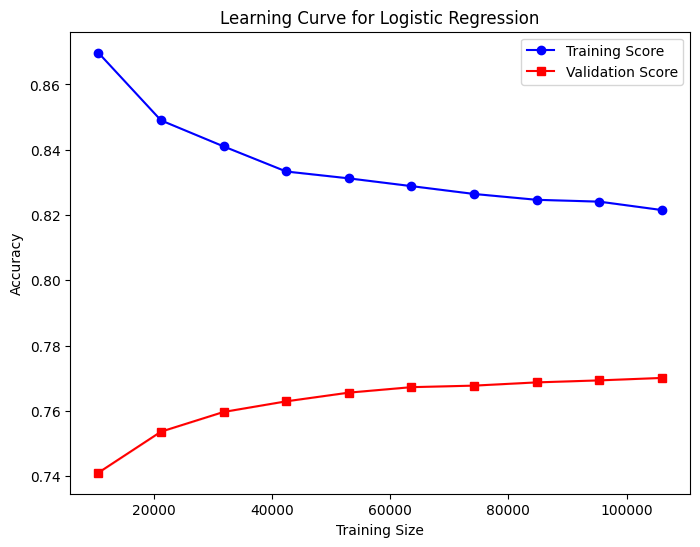

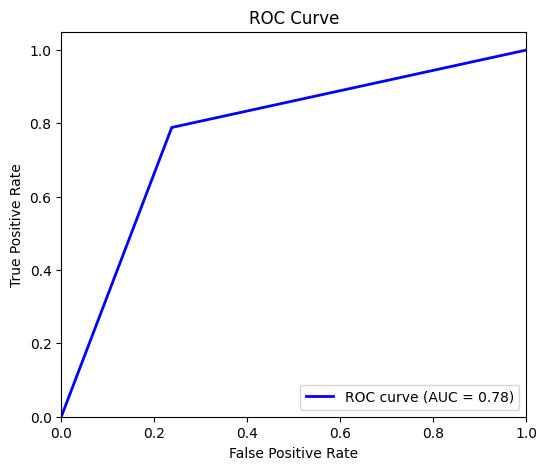

In [22]:
#Libraries to perform stemming and removal of stop words
from nltk.stem import PorterStemmer
stemmer = PorterStemmer()
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
stop_words = list(ENGLISH_STOP_WORDS)

def custom_tokenizer(text):
    #Tokenization
    words = text.split()
    #Removing stopwords
    words = [word for word in words if word not in stop_words]
    #Stemming
    words = [stemmer.stem(word) for word in words]
    
    return words
    
#Reading the training data
train_data["Text"] = train_data["Text"].apply(lambda x: custom_preprocessor(x))
X_train_data = train_data["Text"]
y_train_data = train_data["Label"]
#Reading the validation data
val_data["Text"] = val_data["Text"].apply(lambda x: custom_preprocessor(x))
X_val_data = val_data["Text"]
y_val_data = val_data["Label"]

vectorizer = TfidfVectorizer(tokenizer=custom_tokenizer,token_pattern=None)
#Fitting the tfidfVectorizer and transforming the data
X_train_tfidf = vectorizer.fit_transform(X_train_data)
X_val_tfidf = vectorizer.transform(X_val_data)

model = LogisticRegression(random_state=42,max_iter=500)
#Training the model on the training dataset
model.fit(X_train_tfidf,y_train_data)
#Predictions on the training dataset
y_train_pred = model.predict(X_train_tfidf)
#Predictions on the valuation dataset
y_val_pred = model.predict(X_val_tfidf)

#Classification report and confusion matrix
cr_and_cm(y_val_data,y_val_pred)

#Initializing test_fold with -1, meaning all data points are for training
test_fold = np.full(y_train_data.shape, -1)  
#Setting the validation dataset
test_fold[:len(y_val_data)] = 0  
#Creating the PredefinedSplit
ps = PredefinedSplit(test_fold)

#Creating the learning curve
train_sizes, train_scores, test_scores = learning_curve(
    LogisticRegression(random_state=42,max_iter=500), X_train_tfidf, y_train_data, cv=ps, 
                    scoring="accuracy", train_sizes=np.linspace(0.1, 1.0, 10)
)
#Computing mean and std of accuracy
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

#Plotting the learning curve
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, label="Training Score", color="blue", marker="o")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="blue")
plt.plot(train_sizes, test_mean, label="Validation Score", color="red", marker="s")
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="red")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve for Logistic Regression")
plt.legend()
plt.show()

#ROC curve
ROC_curve(y_val_data,y_val_pred)

### 4)Model with Incorectlly tuned hyperparameters(underfitting) and with text preprocessing
### Worse performance - Overfit present
### Accuracy on testing dataset: 0.72508

              precision    recall  f1-score   support

           0       0.78      0.76      0.77     21197
           1       0.76      0.79      0.78     21199

    accuracy                           0.77     42396
   macro avg       0.77      0.77      0.77     42396
weighted avg       0.77      0.77      0.77     42396



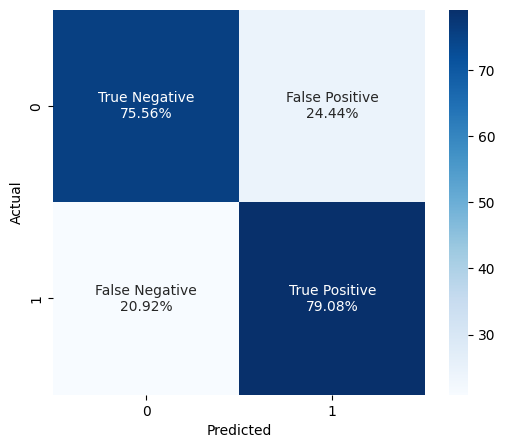

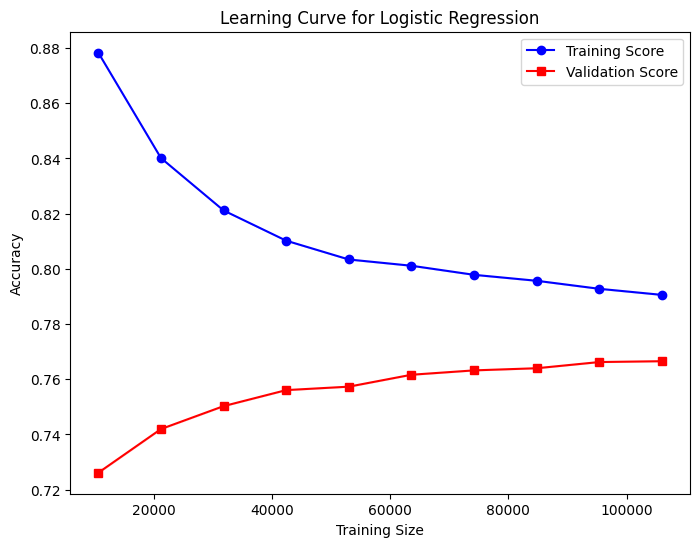

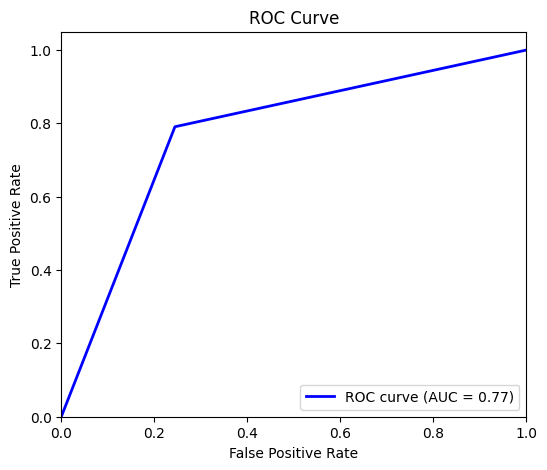

In [23]:
#Reading the training data
train_data["Text"] = train_data["Text"].apply(lambda x: custom_preprocessor(x))
X_train_data = train_data["Text"]
y_train_data = train_data["Label"]
#Reading the validation data
val_data["Text"] = val_data["Text"].apply(lambda x: custom_preprocessor(x))
X_val_data = val_data["Text"]
y_val_data = val_data["Label"]

vectorizer = TfidfVectorizer(tokenizer=custom_tokenizer,token_pattern=None,ngram_range=(1,3),
                             max_df=0.7,min_df=5,max_features=5000,sublinear_tf=True)
#Fitting the tfidfVectorizer and transforming the data
X_train_tfidf = vectorizer.fit_transform(X_train_data)
X_val_tfidf = vectorizer.transform(X_val_data)

model = LogisticRegression(C=6,solver="saga",random_state=42,max_iter=500)
#Training the model on the training dataset
model.fit(X_train_tfidf,y_train_data)
#Predictions on the training dataset
y_train_pred = model.predict(X_train_tfidf)
#Predictions on the valuation dataset
y_val_pred = model.predict(X_val_tfidf)

#Classification report and confusion matrix
cr_and_cm(y_val_data,y_val_pred)

#Initializing test_fold with -1, meaning all data points are for training
test_fold = np.full(y_train_data.shape, -1)  
#Setting the validation dataset
test_fold[:len(y_val_data)] = 0  
#Creating the PredefinedSplit
ps = PredefinedSplit(test_fold)

#Creating the learning curve
train_sizes, train_scores, test_scores = learning_curve(
    LogisticRegression(C=6,solver="saga",random_state=42,max_iter=500), X_train_tfidf, y_train_data, cv=ps, 
                    scoring="accuracy", train_sizes=np.linspace(0.1, 1.0, 10)
)
#Computing mean and std of accuracy
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

#Plotting the learning curve
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, label="Training Score", color="blue", marker="o")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="blue")
plt.plot(train_sizes, test_mean, label="Validation Score", color="red", marker="s")
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="red")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve for Logistic Regression")
plt.legend()
plt.show()

#ROC curve
ROC_curve(y_val_data,y_val_pred)

### 5)Model with fully tuned hyperparameters(overfitting) and with text preprocessing
### Better performance - Overfit present
### Accuracy on testing dataset: 0,80834

              precision    recall  f1-score   support

           0       0.79      0.77      0.78     21197
           1       0.77      0.79      0.78     21199

    accuracy                           0.78     42396
   macro avg       0.78      0.78      0.78     42396
weighted avg       0.78      0.78      0.78     42396



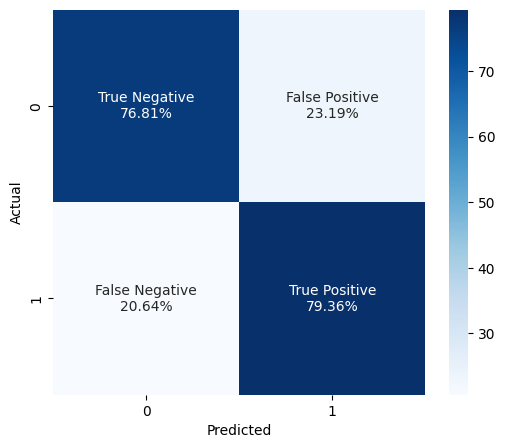

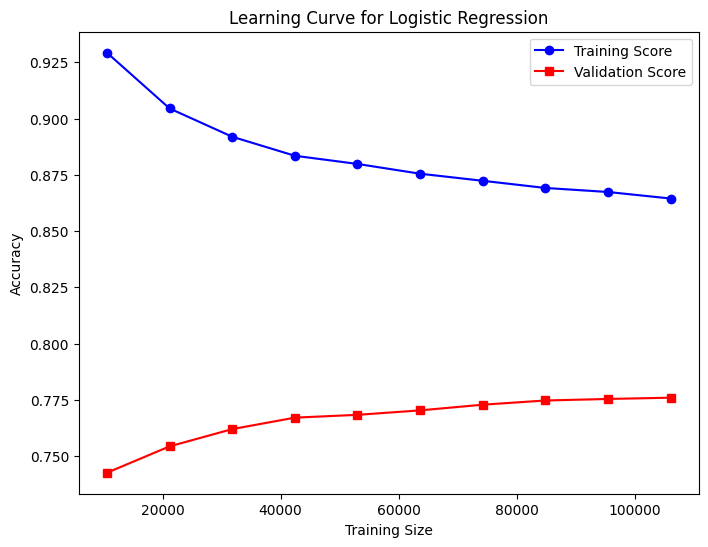

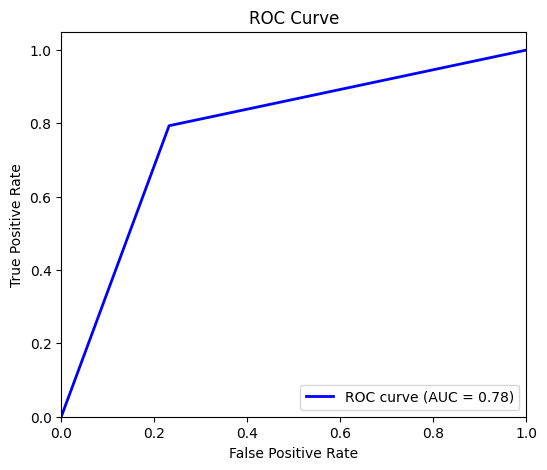

In [24]:
#Reading the training data
train_data["Text"] = train_data["Text"].apply(lambda x: custom_preprocessor(x))
X_train_data = train_data["Text"]
y_train_data = train_data["Label"]
#Reading the validation data
val_data["Text"] = val_data["Text"].apply(lambda x: custom_preprocessor(x))
X_val_data = val_data["Text"]
y_val_data = val_data["Label"]

vectorizer = TfidfVectorizer(tokenizer=custom_tokenizer,token_pattern=None,ngram_range=(1,3),
                             max_df=0.95,min_df=2,sublinear_tf=True)

#Fitting the tfidfVectorizer and transforming the data
X_train_tfidf = vectorizer.fit_transform(X_train_data)
X_val_tfidf = vectorizer.transform(X_val_data)

model = LogisticRegression(C=1.5,solver="saga",random_state=42,max_iter=500)
#Training the model on the training dataset
model.fit(X_train_tfidf,y_train_data)
#Predictions on the training dataset
y_train_pred = model.predict(X_train_tfidf)
#Predictions on the valuation dataset
y_val_pred = model.predict(X_val_tfidf)

#Classification report and confusion matrix
cr_and_cm(y_val_data,y_val_pred)

#Initializing test_fold with -1, meaning all data points are for training
test_fold = np.full(y_train_data.shape, -1)  
#Setting the validation dataset
test_fold[:len(y_val_data)] = 0  
#Creating the PredefinedSplit
ps = PredefinedSplit(test_fold)

#Creating the learning curve
train_sizes, train_scores, test_scores = learning_curve(
    LogisticRegression(C=1.5,solver="saga",random_state=42,max_iter=500), X_train_tfidf, y_train_data, cv=ps, 
                    scoring="accuracy", train_sizes=np.linspace(0.1, 1.0, 10)
)
#Computing mean and std of accuracy
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

#Plotting the learning curve
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, label="Training Score", color="blue", marker="o")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="blue")
plt.plot(train_sizes, test_mean, label="Validation Score", color="red", marker="s")
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="red")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve for Logistic Regression")
plt.legend()
plt.show()

#ROC curve
ROC_curve(y_val_data,y_val_pred)

### 6) Model with fully tuned hyperparameters, text preprocessing and combined training and validation datasets
### Best performance - Overfit present
### Accuracy on testing dataset: 0,81470

In [25]:
#Reading the training data
train_data["Text"] = train_data["Text"].apply(lambda x: custom_preprocessor(x))
X_train_data = train_data["Text"]
y_train_data = train_data["Label"]
#Reading the validation data
val_data["Text"] = val_data["Text"].apply(lambda x: custom_preprocessor(x))
X_val_data = val_data["Text"]
y_val_data = val_data["Label"]

vectorizer = TfidfVectorizer(tokenizer=custom_tokenizer,token_pattern=None,ngram_range=(1,3),
                            max_df=0.95,min_df=2,sublinear_tf=True)
#Fitting the tfidfVectorizer and transforming the data
X_train_tfidf = vectorizer.fit_transform(X_train_data)
X_val_tfidf = vectorizer.transform(X_val_data)

#Combining the train and validation data that were produced by tfidf vectorizer
X_combined_tfidf = vstack([X_train_tfidf, X_val_tfidf])
y_combined_data = np.hstack([y_train_data, y_val_data])

model = LogisticRegression(C=1.5,solver="saga",random_state=42,max_iter=500)
#Training the model on the combined dataset
model.fit(X_combined_tfidf,y_combined_data)

#Predictions on the combined dataset
y_train_pred = model.predict(X_combined_tfidf)

Classification report, confusion matrix and learning curve are not displayed since the validation datased was used for the training process 